# Cleared for Launch: AI Governance Assessment
## ClinicalCompanion — MedAssist AI

**Course:** Data Governance for Generative AI (cd13873)

---

### Scenario

You are an **AI Governance Analyst at MedAssist AI**, preparing **ClinicalCompanion** — a generative AI clinical decision support system — for EU market launch within 3 months. Your manager needs a governance assessment before the board meeting next week.

### Your Deliverables

You will produce **two files** that together cover all six governance deliverables:

| # | Deliverable | Notebook (code + analysis) | Workbook (written analysis) |
|---|---|---|---|
| 1 | EU AI Act Classification | Compliance gap analysis | Classification reasoning + gap table |
| 2 | Risk Register + Heatmap | **Risk heatmap visualization** | Risk details + mitigations |
| 3 | Vendor Evaluation | Vendor scorecard visualization | Evaluation narrative + recommendation |
| 4 | Model Card | Disaggregated performance chart | Model Card content |
| 5 | Monitoring & Incident Response | Monitoring dashboard | KPI definitions + incident plan |
| 6 | Executive Summary | Executive readiness dashboard | Board-ready narrative |

### Project Structure

```
starter/
├── data/                          ← Input datasets (provided — do not modify)
│   ├── system_spec.json           ← ClinicalCompanion system specification
│   ├── training_data_summary.csv  ← Training data sources
│   ├── performance_metrics.csv    ← Model performance by subgroup
│   ├── risk_register.csv          ← Risk register (NIST AI RMF)
│   ├── vendor_assessment.csv      ← Vendor evaluation criteria + scores
│   ├── vendor_profile.json        ← Vendor company profile
│   ├── eu_ai_act_requirements.csv ← EU AI Act compliance requirements
│   ├── monitoring_kpis.csv        ← Monitoring KPI definitions
│   ├── incident_types.csv         ← Incident taxonomy
│   └── severity_levels.csv        ← Incident severity definitions
├── results/                       ← Your outputs will be saved here
├── governance_assessment.ipynb    ← THIS NOTEBOOK (code deliverable)
└── governance_workbook.xlsx       ← Written deliverable (fill in the 6 sheets)
```

### How to Work Through This Notebook

1. Read each step's instructions carefully
2. Look for **🔧 TODO** markers — these are where you write code
3. Run your code and verify the outputs make sense
4. Save all visualizations to `results/`
5. Use insights from your analysis to fill in `governance_workbook.xlsx`

**Estimated time: ~3.5 hours** (notebook) + **~1.5 hours** (workbook) = **5 hours total**

---
## Step 0: Environment Setup

Run this cell to set up your environment. **No changes needed here.**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
from pathlib import Path

# Paths
DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

# Display settings
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Environment ready.")
print(f"Data directory:    {DATA_DIR.resolve()}")
print(f"Results directory:  {RESULTS_DIR.resolve()}")

Environment ready.
Data directory:    E:\vagm\udacity\governance_ia\ai-data-gov-nd700-c2-cd13873-project-starter\ai-data-gov-nd700-c2-cd13873-project-starter\project\starter\data
Results directory:  E:\vagm\udacity\governance_ia\ai-data-gov-nd700-c2-cd13873-project-starter\ai-data-gov-nd700-c2-cd13873-project-starter\project\starter\results


---
## Step 1: Load and Explore the ClinicalCompanion System Specification

**Time estimate: ~20 minutes**

Your first task as a governance analyst is to understand the system you're assessing. Load the system specification and training data summary, then extract the key facts that will inform your governance assessment.

**Key questions to answer:**
- What type of AI system is this? Who uses it?
- What foundation model powers it and how is it accessed?
- What data was it trained on and where does it come from?
- What is the deployment timeline and regulatory status?

### 1a. Load and display the system overview

🔧 **TODO:** Load `system_spec.json` and print a formatted overview of the system. Include at minimum:
- System name, version, type
- Foundation model name, parameters, access method
- Cloud region and security (encryption)
- Target launch date

*Hint: Use `json.load()` to read the file, then access nested keys like `spec['system']['name']`*

In [ ]:
# Step 1a: Load and display system overview

# Load the system specification JSON
with open(DATA_DIR / 'system_spec.json') as f:
    spec = json.load(f)

# Print a formatted header
print("=" * 70)
print("CLINICALCOMPANION v1.0 — SYSTEM OVERVIEW")
print("=" * 70)

# Create a dictionary of key system facts by accessing nested keys in `spec`.
overview = {
    "System": f"{spec['system']['name']} v{spec['system']['version']}",
    "Type": spec['system']['type'],
    "Developer": spec['system']['developer'],
    "Foundation Model": spec['architecture']['foundation_model']['model_name'],
    "Parameters": spec['architecture']['foundation_model']['parameters'],
    "Access Method": spec['architecture']['foundation_model']['access_method'],
    "Cloud Region": spec['architecture']['infrastructure']['region'],
    "Encryption (at rest)": spec['architecture']['infrastructure']['encryption_at_rest'],
    "Encryption (in transit)": spec['architecture']['infrastructure']['encryption_in_transit'],
    "Target Launch Date": spec['system']['release_date_planned'],
}

# Loop through the overview dict and print each fact in a formatted way.
for key, value in overview.items():
    print(f"  {key:<25s}: {value}")

CLINICALCOMPANION v1.0 — SYSTEM OVERVIEW
  System                   : ClinicalCompanion v1.0
  Type                     : Clinical Decision Support System (CDSS)
  Developer                : MedAssist AI
  Foundation Model         : FoundationHealth Medical LLM v3.2
  Parameters               : 7B
  Access Method            : API
  Cloud Region             : eu-west-1 (Frankfurt)
  Encryption (at rest)     : AES-256
  Encryption (in transit)  : TLS 1.3
  Target Launch Date       : 2025-09-01


### 1b. Display intended users and out-of-scope uses

🔧 **TODO:** From the system spec, print:
1. The list of **intended users** (who is allowed to use this system?)
2. The list of **out-of-scope uses** (what is this system NOT for?)

*Think about: Why do these matter for governance? How do they affect risk classification?*

In [3]:
# Step 1b: Print intended users and out-of-scope uses

print("INTENDED USERS:")
for user in spec['intended_use']['intended_users']:
    print(f"- {user}")

print("\nOUT-OF-SCOPE USES:")
for item in spec['intended_use']['out_of_scope']:
    print(f"- {item}")


INTENDED USERS:


NameError: name 'spec' is not defined

### 1c. Load and explore training data sources

🔧 **TODO:** Load `training_data_summary.csv` and display:
1. A table of all training data sources with their record counts and geography
2. The total number of training records

*Think about: What geographic gaps do you see? How might this affect fairness?*

In [2]:
# Step 1c: Load and display training data summary

training_df = pd.read_csv(DATA_DIR / 'training_data_summary.csv')

print("=" * 70)
print("TRAINING DATA SOURCES")
print("=" * 70)

# Display requested columns without row index.
cols = ['source_name', 'record_count', 'geography', 'data_type']
print(training_df[cols].to_string(index=False))

# Print total training records with comma formatting.
total_records = training_df['record_count'].sum()
print(f"\nTotal training records: {total_records:,}")

TRAINING DATA SOURCES
                    source_name  record_count                    geography                    data_type
Partner Hospital Network A (EU)        280000 Germany, France, Netherlands               EHR encounters
Partner Hospital Network B (US)        170000  United States (multi-state)               EHR encounters
         PubMed Abstract Corpus       2100000                       Global Medical literature abstracts
            Expert Clinical Q&A         12000                       EU, US            Curated Q&A pairs
   Clinical Practice Guidelines           340                  EU, US, WHO          Practice guidelines

Total training records: 2,562,340


---
## Step 2: EU AI Act Risk Classification

**Time estimate: ~45 minutes**

This is one of the most important governance tasks. You need to walk through the EU AI Act's classification framework and determine ClinicalCompanion's risk level. Then analyze compliance gaps.

**EU AI Act Classification Decision Tree:**
1. **Article 5 — Prohibited practices?** (social scoring, exploitation, subliminal manipulation, real-time biometric ID)
2. **Article 6(1) — Safety component under EU harmonisation legislation?** (check if it falls under MDR, machinery, toys, etc.)
3. **Annex III — High-risk use cases?** (biometric ID, critical infrastructure, education, employment, essential services, law enforcement, migration, justice)
4. If none of the above → Limited risk or minimal risk

### 2a. Prohibited practices check

🔧 **TODO:** For each prohibited practice under Article 5, evaluate whether ClinicalCompanion engages in it. Print a clear pass/fail for each one with a brief justification.

*The four prohibited categories are: social scoring, exploiting vulnerabilities, real-time remote biometric identification, and subliminal manipulation.*

In [5]:
# Step 2a: Evaluate Article 5 prohibited practices

print("STEP 1: Prohibited Practices Check (Article 5)")
print("-" * 50)

# Ensure system spec is available in this cell run.
if 'spec' not in globals():
    with open(DATA_DIR / 'system_spec.json') as f:
        spec = json.load(f)

# The four prohibited categories to check against
prohibited_practices = [
    "Social scoring by public authorities",
    "Exploiting vulnerabilities",
    "Real-time remote biometric identification",
    "Subliminal manipulation"
]

evaluations = {
    "Social scoring by public authorities": (
        False,
        "System is clinical decision support for physicians, not public-authority social scoring."
    ),
    "Exploiting vulnerabilities": (
        False,
        "Designed for licensed clinicians in supervised care settings; not targeted at vulnerable users."
    ),
    "Real-time remote biometric identification": (
        False,
        "No biometric identification function; processes clinical records and generates diagnostic support."
    ),
    "Subliminal manipulation": (
        False,
        "Provides transparent suggestions with physician review; no subliminal behavior manipulation."
    )
}

# Evaluate each prohibited practice with a clear result.
for practice in prohibited_practices:
    is_engaged, reason = evaluations[practice]
    result = "FAIL" if is_engaged else "PASS"
    print(f"[{result}] {practice}")
    print(f"  Reason: {reason}")

# Conclusion for Article 5.
engages_any_prohibited = any(flag for flag, _ in evaluations.values())
if engages_any_prohibited:
    print("\nConclusion: FAIL — At least one Article 5 prohibited practice is engaged.")
else:
    print("\nConclusion: PASS — No Article 5 prohibited practices identified.")

STEP 1: Prohibited Practices Check (Article 5)
--------------------------------------------------
[PASS] Social scoring by public authorities
  Reason: System is clinical decision support for physicians, not public-authority social scoring.
[PASS] Exploiting vulnerabilities
  Reason: Designed for licensed clinicians in supervised care settings; not targeted at vulnerable users.
[PASS] Real-time remote biometric identification
  Reason: No biometric identification function; processes clinical records and generates diagnostic support.
[PASS] Subliminal manipulation
  Reason: Provides transparent suggestions with physician review; no subliminal behavior manipulation.

Conclusion: PASS — No Article 5 prohibited practices identified.


### 2b. High-risk classification

🔧 **TODO:** Determine whether ClinicalCompanion qualifies as HIGH-RISK. Consider:

1. **Is it a safety component under EU harmonisation legislation?** (Article 6(1))
   - Is ClinicalCompanion a medical device under MDR 2017/745?
   - If yes, what MDR class would it be? (Class I, IIa, IIb, or III?)

2. **Does it fall under Annex III high-risk use cases?**

Print your classification with the legal basis (which Article and Annex).

*Hint: A clinical decision support system that assists physicians with diagnoses falls under medical device regulation.*

In [6]:
# Step 2b: Walk through the high-risk classification decision tree

print("STEP 2: Safety Component Under EU Harmonisation Legislation?")
print("-" * 50)

# Ensure system spec is available in this cell run.
if 'spec' not in globals():
    with open(DATA_DIR / 'system_spec.json') as f:
        spec = json.load(f)

is_medical_device = True
mdr_class = "Likely Class IIa"
requires_conformity_assessment = True

print(f"Medical device under MDR 2017/745: {'Yes' if is_medical_device else 'No'}")
print(
    "Justification: The system provides diagnostic support to clinicians and influences "
    "clinical decision-making, which places it within medical device scope."
)
print(f"Likely MDR class: {mdr_class}")
print(
    "Justification: As a decision support tool for diagnosis/treatment consideration without "
    "fully autonomous action, a Class IIa assumption is reasonable for governance planning."
)
print(f"Requires conformity assessment: {'Yes' if requires_conformity_assessment else 'No'}")
print("Justification: Class IIa devices require notified body involvement for CE marking.")

print("\nSTEP 3: Annex III High-Risk Use Cases?")
print("-" * 50)
annex_iii_match = False
print(
    "No direct Annex III category match identified (biometrics, education, employment, law "
    "enforcement, migration, justice, etc.)."
)
print(
    "However, this does not change classification because Article 6(1) already applies through MDR."
)

# Final classification with legal basis.
print("\n" + "=" * 70)
print("FINAL CLASSIFICATION: HIGH-RISK AI SYSTEM")
print("Legal basis: EU AI Act Article 6(1) via MDR-regulated medical device context.")
print("Annex III note: Not required for high-risk determination in this case.")

STEP 2: Safety Component Under EU Harmonisation Legislation?
--------------------------------------------------
Medical device under MDR 2017/745: Yes
Justification: The system provides diagnostic support to clinicians and influences clinical decision-making, which places it within medical device scope.
Likely MDR class: Likely Class IIa
Justification: As a decision support tool for diagnosis/treatment consideration without fully autonomous action, a Class IIa assumption is reasonable for governance planning.
Requires conformity assessment: Yes
Justification: Class IIa devices require notified body involvement for CE marking.

STEP 3: Annex III High-Risk Use Cases?
--------------------------------------------------
No direct Annex III category match identified (biometrics, education, employment, law enforcement, migration, justice, etc.).
However, this does not change classification because Article 6(1) already applies through MDR.

FINAL CLASSIFICATION: HIGH-RISK AI SYSTEM
Legal basis

### 2c. Compliance gap analysis

🔧 **TODO:** Load `eu_ai_act_requirements.csv` and analyze the compliance gaps:
1. Print each requirement with its current status and severity
2. Calculate and print a summary: how many Critical, High, Medium, Low gaps exist?

*Use emoji or symbols to make the status easy to scan (e.g., ✅ Compliant, ⚠️ Partial, 🔶 In Progress)*

*Think about: Which gaps are most urgent? What's the critical path to compliance?*

In [7]:
# Step 2c: Load and analyze EU AI Act compliance requirements

compliance_df = pd.read_csv(DATA_DIR / 'eu_ai_act_requirements.csv')

print("COMPLIANCE REQUIREMENTS (Articles 8-15):")
print("-" * 70)

status_icon = {
    'Compliant': '✅',
    'In Progress': '🔶',
    'Partial': '⚠️',
    'Not Started': '❌',
    'Planned': '🟨'
}

# Print each requirement with status and severity.
for _, row in compliance_df.iterrows():
    icon = status_icon.get(row['current_status'], '•')
    print(
        f"{icon} {row['article']} | {row['requirement_name']} | "
        f"Status: {row['current_status']} | Severity: {row['severity']}"
    )

# Print gap summary by severity in a fixed order.
print("\nGAP SUMMARY:")
severity_order = ['Critical', 'High', 'Medium', 'Low']
severity_counts = compliance_df['severity'].value_counts().reindex(severity_order, fill_value=0)
for sev in severity_order:
    print(f"- {sev}: {severity_counts[sev]}")

COMPLIANCE REQUIREMENTS (Articles 8-15):
----------------------------------------------------------------------
⚠️ Article 9 | Risk Management System | Status: Partial | Severity: High
🔶 Article 9 | Risk Identification | Status: In Progress | Severity: Medium
❌ Article 9 | Residual Risk Evaluation | Status: Not Started | Severity: High
⚠️ Article 10 | Data Governance | Status: Partial | Severity: High
⚠️ Article 10 | Dataset Representativeness | Status: Partial | Severity: High
🔶 Article 10 | Special Category Data | Status: In Progress | Severity: Medium
🔶 Article 11 | Technical Documentation | Status: In Progress | Severity: Medium
⚠️ Article 12 | Record-Keeping | Status: Partial | Severity: Medium
🟨 Article 12 | Log Retention | Status: Planned | Severity: Medium
⚠️ Article 13 | Transparency | Status: Partial | Severity: Medium
🔶 Article 13 | Instructions for Use | Status: In Progress | Severity: Medium
✅ Article 14 | Human Oversight | Status: Compliant | Severity: Low
✅ Article 14 | 

---
## Step 3: Risk Assessment (NIST AI RMF)

**Time estimate: ~30 minutes**

Load the risk register and analyze the 8 identified risks. The risks are organized by NIST AI RMF functions (Govern, Map, Measure, Manage).

**Key analysis tasks:**
- Load and display the risk register
- Calculate summary statistics (average score, max score, priority distribution)
- Identify which NIST functions have the most risk concentration
- Compare pre-mitigation vs. post-mitigation scores to assess effectiveness

### 3a. Load and summarize the risk register

🔧 **TODO:** Load `risk_register.csv` and display:
1. A summary table showing: risk_id, category, NIST function, likelihood, impact, risk score, priority
2. Key statistics: total risks, count by priority (Critical/High/Medium), average and max scores

*Hint: The risk_score column = likelihood × impact (5×5 scale, max 25)*

In [9]:
# Step 3a: Load risk register and display summary

risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

print("=" * 70)
print("RISK REGISTER — ClinicalCompanion v1.0 (NIST AI RMF)")
print("=" * 70)

# Display summary table without index.
summary_cols = [
    'risk_id', 'risk_category', 'nist_rmf_function',
    'likelihood', 'impact', 'risk_score', 'priority'
]
print(risk_df[summary_cols].to_string(index=False))

# Print key statistics.
print(f"\n{'─' * 40}")
print(f"Total risks: {len(risk_df)}")
print(f"Critical priority risks: {(risk_df['priority'] == 'Critical').sum()}")
print(f"High priority risks: {(risk_df['priority'] == 'High').sum()}")
print(f"Average risk score: {risk_df['risk_score'].mean():.1f}")
print(f"Maximum risk score: {risk_df['risk_score'].max()}")

RISK REGISTER — ClinicalCompanion v1.0 (NIST AI RMF)
risk_id      risk_category nist_rmf_function  likelihood  impact  risk_score priority
  R-001          Technical           Measure           4       5          20 Critical
  R-002     Ethical / Bias               Map           4       4          16     High
  R-003 Legal / Regulatory            Govern           3       5          15     High
  R-004 Privacy / Security            Manage           3       5          15     High
  R-005        Operational            Manage           3       4          12     High
  R-006          Technical           Measure           3       4          12     High
  R-007   Ethical / Safety               Map           3       5          15     High
  R-008 Legal / Regulatory            Govern           3       5          15     High

────────────────────────────────────────
Total risks: 8
Critical priority risks: 1
High priority risks: 7
Average risk score: 15.0
Maximum risk score: 20


### 3b. Analyze risk distribution by NIST AI RMF function

🔧 **TODO:** Group the risks by their `nist_rmf_function` and calculate:
- Number of risks per function
- Average risk score per function
- Which function carries the highest total risk?

*The four NIST AI RMF functions are: Govern, Map, Measure, Manage*

In [10]:
# Step 3b: Analyze risks by NIST AI RMF function

# Group risk data by NIST RMF function.
rmf_summary = (
    risk_df.groupby('nist_rmf_function', as_index=False)
    .agg(
        risk_count=('risk_id', 'count'),
        avg_risk_score=('risk_score', 'mean'),
        total_risk_score=('risk_score', 'sum')
    )
    .sort_values('total_risk_score', ascending=False)
)

print("RISK DISTRIBUTION BY NIST AI RMF FUNCTION")
print("-" * 50)
print(rmf_summary.to_string(index=False, formatters={'avg_risk_score': '{:.1f}'.format}))

# Identify highest total risk function.
highest_row = rmf_summary.iloc[0]
print(
    f"\nHighest total risk function: {highest_row['nist_rmf_function']} "
    f"(total score = {highest_row['total_risk_score']})"
)

RISK DISTRIBUTION BY NIST AI RMF FUNCTION
--------------------------------------------------
nist_rmf_function  risk_count avg_risk_score  total_risk_score
          Measure           2           16.0                32
              Map           2           15.5                31
           Govern           2           15.0                30
           Manage           2           13.5                27

Highest total risk function: Measure (total score = 32)


### 3c. Mitigation effectiveness analysis

🔧 **TODO:** Compare pre-mitigation scores vs. post-mitigation (residual) scores:
1. For each risk, calculate the percentage reduction
2. Print the total pre-mitigation score, total post-mitigation score, and overall reduction %
3. Which risk has the largest absolute reduction? Which has the smallest?

*This analysis will feed into the risk heatmap you'll create next.*

In [12]:
# Step 3c: Analyze mitigation effectiveness

# Calculate reduction metrics per risk.
risk_df['absolute_reduction'] = risk_df['risk_score'] - risk_df['residual_score']
risk_df['reduction_pct'] = np.where(
    risk_df['risk_score'] > 0,
    (risk_df['absolute_reduction'] / risk_df['risk_score']) * 100,
    0
)

print("MITIGATION EFFECTIVENESS BY RISK")
print("-" * 50)
for _, row in risk_df.iterrows():
    print(
        f"{row['risk_id']}: pre={row['risk_score']}, post={row['residual_score']}, "
        f"reduction={row['reduction_pct']:.1f}%"
    )

# Portfolio-level totals.
total_pre = risk_df['risk_score'].sum()
total_post = risk_df['residual_score'].sum()
overall_reduction_pct = ((total_pre - total_post) / total_pre) * 100 if total_pre > 0 else 0

print("\nPORTFOLIO SUMMARY")
print("-" * 50)
print(f"Total pre-mitigation score: {total_pre}")
print(f"Total post-mitigation score: {total_post}")
print(f"Overall reduction: {overall_reduction_pct:.1f}%")

# Largest and smallest absolute reductions (including ties).
max_reduction = risk_df['absolute_reduction'].max()
min_reduction = risk_df['absolute_reduction'].min()
largest_risks = risk_df.loc[risk_df['absolute_reduction'] == max_reduction, 'risk_id'].tolist()
smallest_risks = risk_df.loc[risk_df['absolute_reduction'] == min_reduction, 'risk_id'].tolist()

print("\nREDUCTION EXTREMES")
print("-" * 50)
print(f"Largest absolute reduction: {', '.join(largest_risks)} ({max_reduction} points)")
print(f"Smallest absolute reduction: {', '.join(smallest_risks)} ({min_reduction} points)")

MITIGATION EFFECTIVENESS BY RISK
--------------------------------------------------
R-001: pre=20, post=10, reduction=50.0%
R-002: pre=16, post=8, reduction=50.0%
R-003: pre=15, post=5, reduction=66.7%
R-004: pre=15, post=10, reduction=33.3%
R-005: pre=12, post=8, reduction=33.3%
R-006: pre=12, post=6, reduction=50.0%
R-007: pre=15, post=8, reduction=46.7%
R-008: pre=15, post=8, reduction=46.7%

PORTFOLIO SUMMARY
--------------------------------------------------
Total pre-mitigation score: 120
Total post-mitigation score: 63
Overall reduction: 47.5%

REDUCTION EXTREMES
--------------------------------------------------
Largest absolute reduction: R-001, R-003 (10 points)
Smallest absolute reduction: R-005 (4 points)


---
## Step 4: Risk Heatmap Visualization

**Time estimate: ~40 minutes**

This is the main visualization deliverable. Create a professional risk heatmap that maps the 8 risks on a 5×5 likelihood × impact matrix, plus a companion chart showing risk scores.

**Requirements:**
- 5×5 grid with color gradient (green→yellow→orange→red)
- Each risk plotted at its (likelihood, impact) position
- Risk IDs labeled on each point
- Critical risks visually distinguished (different marker)
- A second chart showing risk scores as horizontal bars

### 4a. Create the risk heatmap

🔧 **TODO:** Create a figure with two subplots side-by-side:

**Left panel — 5×5 Risk Heatmap:**
- Background colored by risk score (likelihood × impact) using a green-to-red colormap
- White grid lines separating cells
- Each risk plotted as a scatter point at its (likelihood-1, impact-1) position (0-indexed)
- Critical risks: square markers, larger size
- High risks: circle markers
- Risk IDs annotated near each point
- Risk score numbers faintly visible in each cell
- Axis labels: "Likelihood →" and "Impact →" with descriptive tick labels
- Legend showing risk level color bands

**Right panel — Risk Score Bar Chart:**
- Horizontal bars showing each risk's score
- Colored by priority (Critical = darker red)
- Risk scores labeled on each bar
- Reference lines at score 10 and 15

Save as `results/risk_heatmap.png` with `dpi=150`.

*Hints:*
- *Use `plt.subplots(1, 2, figsize=(20, 8))` for side-by-side layout*
- *Use `imshow()` for the heatmap background*
- *Use `scatter()` to plot individual risks*
- *Use `annotate()` to label risk IDs*

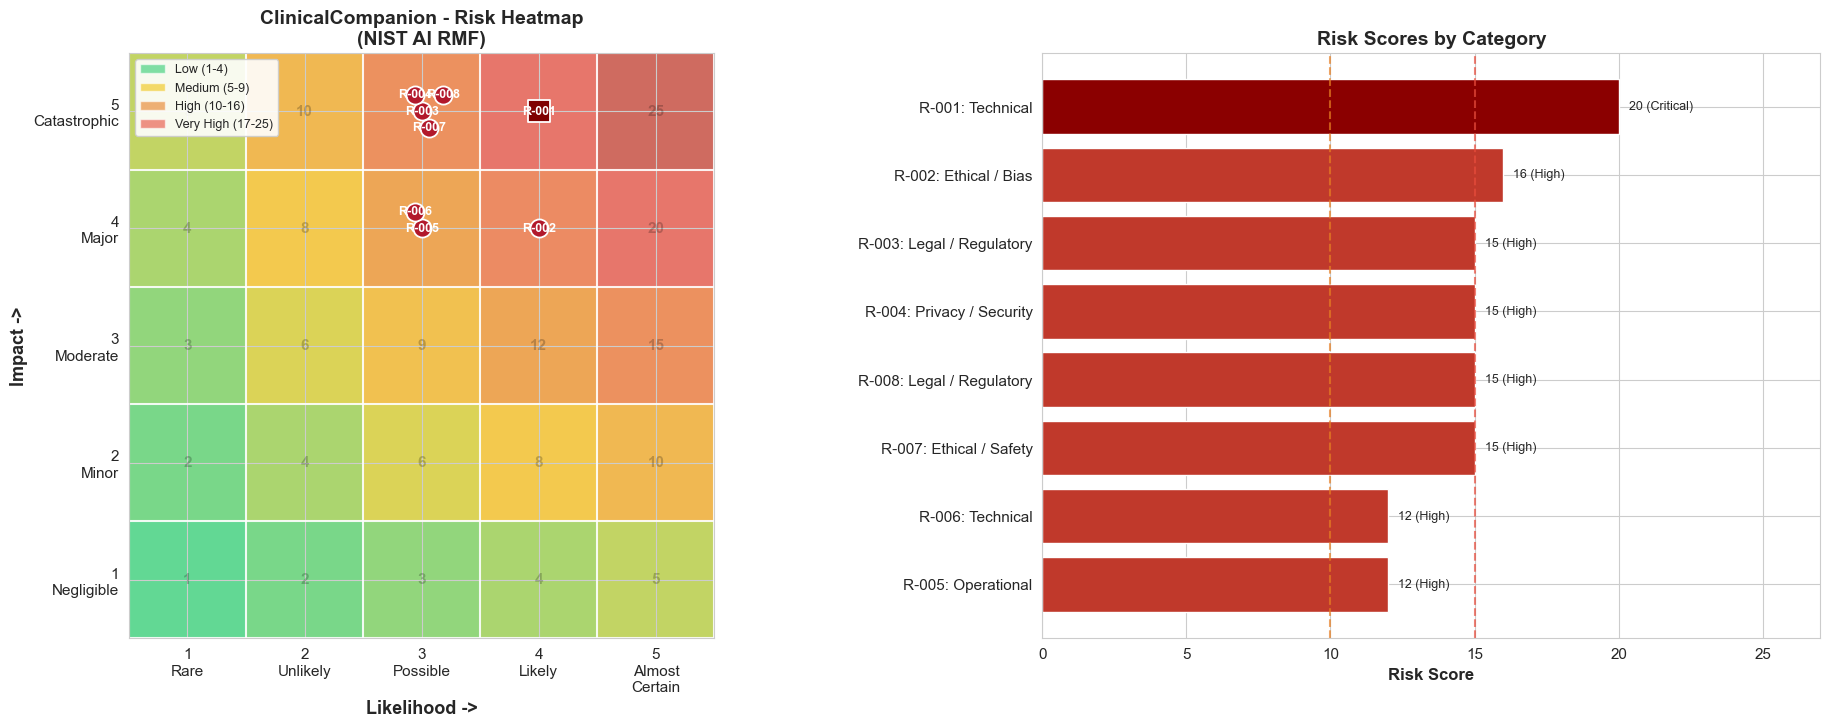

Saved: results/risk_heatmap.png


In [14]:
# Step 4a: Create the risk heatmap visualization
from matplotlib.colors import LinearSegmentedColormap

# Re-load risk data (in case you modified risk_df above)
risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8),
                                gridspec_kw={'width_ratios': [1.2, 1]})

# --- LEFT PANEL: 5x5 Risk Heatmap ---

# Score matrix for background coloring (each cell = likelihood x impact)
score_matrix = np.array([[(i+1)*(j+1) for j in range(5)] for i in range(5)])

# Color gradient: green (low risk) -> red (high risk)
cmap = LinearSegmentedColormap.from_list('risk',
       ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b'], N=256)

# Display heatmap background.
ax1.imshow(score_matrix, cmap=cmap, origin='lower', vmin=1, vmax=25, alpha=0.75)

# Draw white grid lines to separate cells.
for i in np.arange(-0.5, 5.5, 1):
    ax1.axhline(i, color='white', lw=1.5, alpha=0.9)
    ax1.axvline(i, color='white', lw=1.5, alpha=0.9)

# Plot risks and annotate IDs. Offset overlapping points slightly.
position_counts = {}
for _, r in risk_df.iterrows():
    x = r['likelihood'] - 1
    y = r['impact'] - 1
    key = (x, y)
    offset_idx = position_counts.get(key, 0)
    position_counts[key] = offset_idx + 1

    # Small deterministic offsets for overlapping markers.
    dx = (-0.18 + 0.12 * (offset_idx % 4)) if offset_idx > 0 else 0
    dy = (0.14 if offset_idx % 2 else -0.14) if offset_idx > 0 else 0

    is_critical = r['priority'] == 'Critical'
    marker = 's' if is_critical else 'o'
    size = 230 if is_critical else 170
    face = '#7f0000' if is_critical else '#b2182b'

    ax1.scatter(x + dx, y + dy, s=size, marker=marker, c=face,
                edgecolors='white', linewidths=1.3, zorder=3)
    ax1.annotate(r['risk_id'], (x + dx, y + dy), xytext=(0, 0), textcoords='offset points',
                 ha='center', va='center', fontsize=9, fontweight='bold', color='white', zorder=4)

# Add faint score numbers in each cell center.
for yi in range(5):
    for xi in range(5):
        ax1.text(xi, yi, str(score_matrix[yi, xi]), ha='center', va='center',
                 fontsize=11, color='black', alpha=0.22, fontweight='bold', zorder=2)

# Axis labels and formatting (provided)
ax1.set_xlabel('Likelihood ->', fontsize=13, fontweight='bold')
ax1.set_ylabel('Impact ->', fontsize=13, fontweight='bold')
ax1.set_title('ClinicalCompanion - Risk Heatmap\n(NIST AI RMF)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(5))
ax1.set_xticklabels(['1\nRare','2\nUnlikely','3\nPossible','4\nLikely','5\nAlmost\nCertain'])
ax1.set_yticks(range(5))
ax1.set_yticklabels(['1\nNegligible','2\nMinor','3\nModerate','4\nMajor','5\nCatastrophic'])
ax1.legend(handles=[
    mpatches.Patch(fc='#2ecc71', alpha=0.6, label='Low (1-4)'),
    mpatches.Patch(fc='#f1c40f', alpha=0.6, label='Medium (5-9)'),
    mpatches.Patch(fc='#e67e22', alpha=0.6, label='High (10-16)'),
    mpatches.Patch(fc='#e74c3c', alpha=0.6, label='Very High (17-25)'),
], loc='upper left', fontsize=9, framealpha=0.9)


# --- RIGHT PANEL: Risk Score Bar Chart ---

risk_sorted = risk_df.sort_values('risk_score', ascending=False).reset_index(drop=True)
bar_colors = risk_sorted['priority'].map({'Critical': '#8b0000', 'High': '#c0392b'}).fillna('#d95f0e')

bars = ax2.barh(range(len(risk_sorted)), risk_sorted['risk_score'],
                color=bar_colors, edgecolor='white', linewidth=1.0)

# Add score and priority labels to the right of bars.
for i, (_, r) in enumerate(risk_sorted.iterrows()):
    ax2.text(r['risk_score'] + 0.35, i,
             f"{r['risk_score']} ({r['priority']})",
             va='center', fontsize=9)

# Add reference lines.
ax2.axvline(x=10, color='#e67e22', ls='--', lw=1.5, alpha=0.7)
ax2.axvline(x=15, color='#e74c3c', ls='--', lw=1.5, alpha=0.7)

# Axis formatting (provided)
ax2.set_yticks(range(len(risk_sorted)))
ax2.set_yticklabels([f"{r['risk_id']}: {r['risk_category']}" for _, r in risk_sorted.iterrows()])
ax2.set_xlabel('Risk Score', fontsize=12, fontweight='bold')
ax2.set_title('Risk Scores by Category', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 27)
ax2.invert_yaxis()

# Save
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'risk_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: results/risk_heatmap.png')

### 4b. Create the pre vs. post-mitigation comparison chart

🔧 **TODO:** Create a grouped bar chart comparing pre-mitigation and post-mitigation risk scores:
- Side-by-side bars (red = pre, green = post) for each risk
- Score labels on top of each bar
- Percentage reduction annotated above each pair
- Reference lines at scores 10 and 15
- Save as `results/risk_mitigation_comparison.png`

*Hint: Use `np.arange()` for bar positions and offset by bar width/2 for grouping*

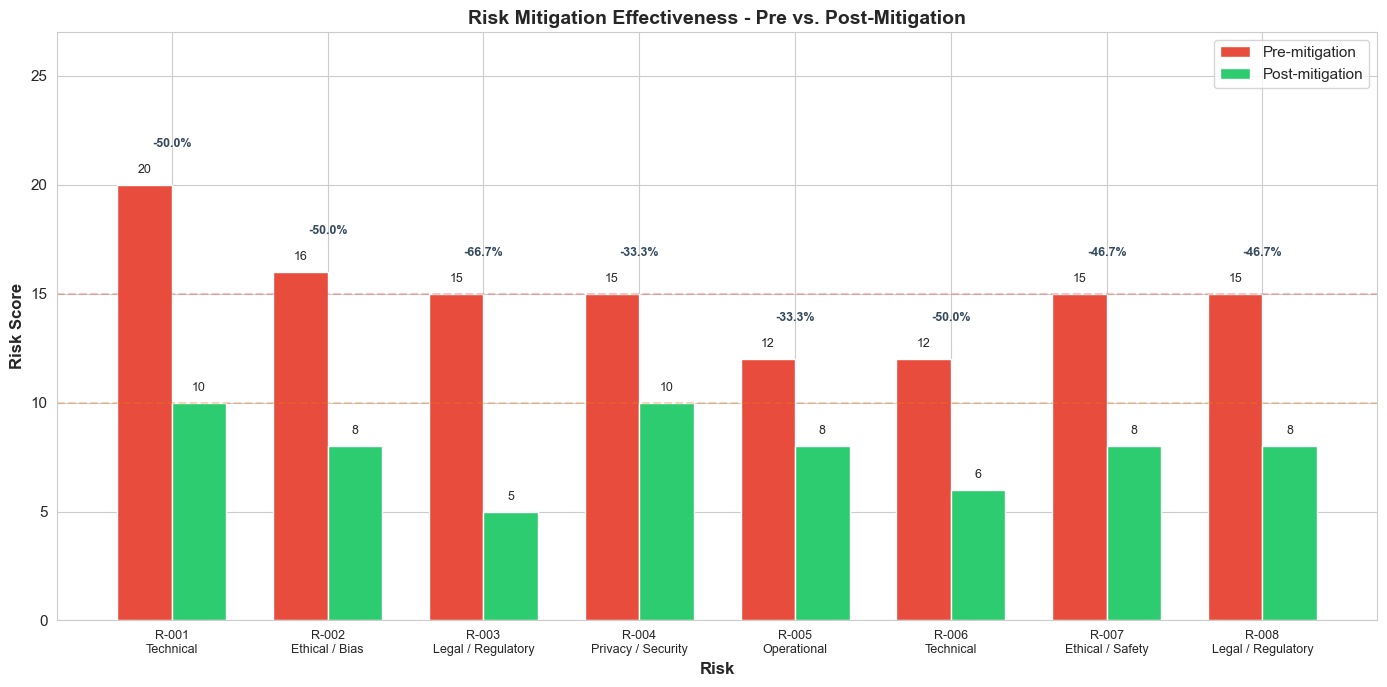

Saved: results/risk_mitigation_comparison.png


In [15]:
# Step 4b: Create pre vs. post-mitigation comparison

# Ensure risk data exists in this cell's execution context.
if 'risk_df' not in globals():
    risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(risk_df))
w = 0.35  # bar width

# Build grouped bars: pre (left) vs post (right).
pre_vals = risk_df['risk_score'].values
post_vals = risk_df['residual_score'].values
pre_bars = ax.bar(x - w/2, pre_vals, width=w, color='#e74c3c', label='Pre-mitigation', edgecolor='white')
post_bars = ax.bar(x + w/2, post_vals, width=w, color='#2ecc71', label='Post-mitigation', edgecolor='white')

# Add score labels on each bar.
for b in list(pre_bars) + list(post_bars):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 0.4, f"{h:.0f}",
            ha='center', va='bottom', fontsize=9)

# Compute and annotate reduction percentages above each pair.
reduction_pct = np.where(pre_vals > 0, ((pre_vals - post_vals) / pre_vals) * 100, 0)
for i, pct in enumerate(reduction_pct):
    ymax = max(pre_vals[i], post_vals[i])
    ax.text(x[i], ymax + 1.6, f"-{pct:.1f}%", ha='center', va='bottom',
            fontsize=9, color='#34495e', fontweight='bold')

# Axis formatting (provided)
ax.set_xlabel('Risk', fontsize=12, fontweight='bold')
ax.set_ylabel('Risk Score', fontsize=12, fontweight='bold')
ax.set_title('Risk Mitigation Effectiveness - Pre vs. Post-Mitigation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['risk_id']}\n{r['risk_category']}" for _, r in risk_df.iterrows()], fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, 27)
ax.axhline(y=15, color='#e74c3c', ls='--', alpha=0.3)
ax.axhline(y=10, color='#e67e22', ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'risk_mitigation_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: results/risk_mitigation_comparison.png')

---
## Step 5: Vendor Evaluation Visualization

**Time estimate: ~30 minutes**

Load the vendor assessment data and create a governance scorecard. The vendor (FoundationHealth Inc.) has been evaluated across 27 criteria in 5 categories.

*Full evaluation narrative goes in `governance_workbook.xlsx` → Sheet "Vendor Evaluation"*

### 5a. Load and analyze vendor data

🔧 **TODO:** Load `vendor_assessment.csv` and `vendor_profile.json`, then:
1. Calculate the score percentage for each category (score / max_score × 100)
2. Calculate the overall vendor score
3. Print a summary showing each category's score and the overall rating

*Scoring guide: ≥80% = Low Risk, 60-79% = Medium Risk, <60% = High Risk*

In [16]:
# Step 5a: Load and analyze vendor assessment data

vendor_df = pd.read_csv(DATA_DIR / 'vendor_assessment.csv')
with open(DATA_DIR / 'vendor_profile.json') as f:
    vendor = json.load(f)

# Aggregate scores by category and compute percentages.
category_scores = (
    vendor_df.groupby('category', as_index=False)
    .agg(
        score=('score', 'sum'),
        max_score=('max_score', 'sum')
    )
)
category_scores['score_pct'] = (category_scores['score'] / category_scores['max_score']) * 100

# Classify vendor risk level by score percentage.
def vendor_risk_level(pct):
    if pct >= 80:
        return 'Low Risk'
    if pct >= 60:
        return 'Medium Risk'
    return 'High Risk'

category_scores['risk_level'] = category_scores['score_pct'].apply(vendor_risk_level)
category_scores = category_scores.sort_values('score_pct', ascending=False).reset_index(drop=True)

print(f"VENDOR EVALUATION SUMMARY - {vendor['company']['name']}")
print("-" * 70)
for _, row in category_scores.iterrows():
    print(
        f"{row['category']}: {int(row['score'])}/{int(row['max_score'])} "
        f"({row['score_pct']:.1f}%) - {row['risk_level']}"
    )

# Calculate overall score.
total_score = vendor_df['score'].sum()
total_max = vendor_df['max_score'].sum()
overall_pct = (total_score / total_max) * 100
overall_risk = vendor_risk_level(overall_pct)

print("\nOVERALL VENDOR SCORE")
print("-" * 70)
print(f"Total: {total_score}/{total_max} ({overall_pct:.1f}%) - {overall_risk}")

VENDOR EVALUATION SUMMARY - FoundationHealth Inc.
----------------------------------------------------------------------
Data Privacy & Security: 25/30 (83.3%) - Low Risk
Contractual & Business Continuity: 18/30 (60.0%) - Medium Risk
Model Governance & Lifecycle: 15/25 (60.0%) - Medium Risk
Model Transparency & Documentation: 15/25 (60.0%) - Medium Risk
Regulatory & Ethical Alignment: 15/25 (60.0%) - Medium Risk

OVERALL VENDOR SCORE
----------------------------------------------------------------------
Total: 88/135 (65.2%) - Medium Risk


### 5b. Create vendor scorecard visualization

🔧 **TODO:** Create a figure with two subplots:

**Left — Horizontal bar chart:**
- One bar per vendor category showing score percentage
- Color-coded: green (≥80%), yellow (60-79%), red (<60%)
- Score labels showing "XX% (score/max)" on each bar
- Reference lines at 60% and 80%

**Right — Radar/spider chart:**
- Categories around the perimeter
- Score percentages as the radar values
- Reference circles at 60% and 80%

Save as `results/vendor_evaluation_chart.png`.

*Hint: For the radar chart, use `fig.add_subplot(122, polar=True)` and compute angles with `np.linspace(0, 2*np.pi, n, endpoint=False)`*

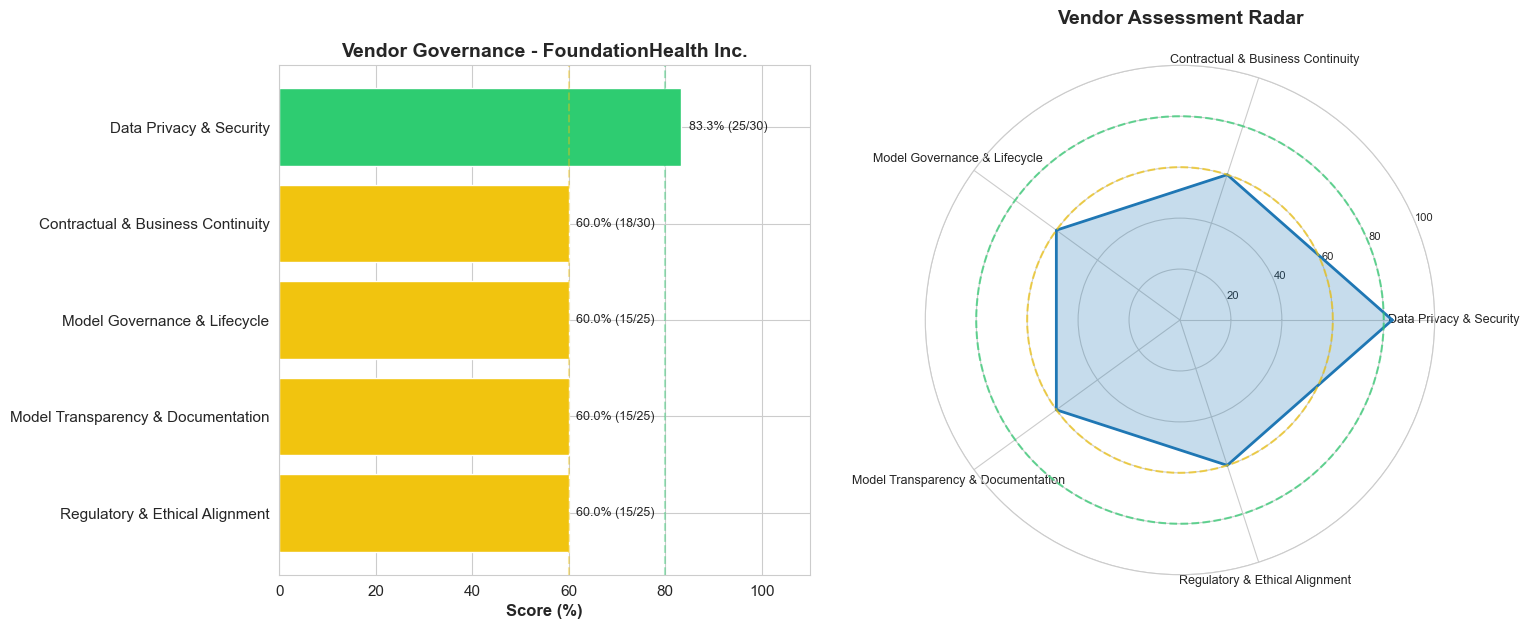

Saved: results/vendor_evaluation_chart.png


In [17]:
# Step 5b: Create vendor scorecard visualization

# Ensure data is available even if this cell is run independently.
if 'vendor_df' not in globals():
    vendor_df = pd.read_csv(DATA_DIR / 'vendor_assessment.csv')
if 'vendor' not in globals():
    with open(DATA_DIR / 'vendor_profile.json') as f:
        vendor = json.load(f)
if 'category_scores' not in globals():
    category_scores = (
        vendor_df.groupby('category', as_index=False)
        .agg(score=('score', 'sum'), max_score=('max_score', 'sum'))
    )
    category_scores['score_pct'] = (category_scores['score'] / category_scores['max_score']) * 100

fig, (ax1, ax2_placeholder) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PANEL: Horizontal Bar Chart ---

plot_df = category_scores.sort_values('score_pct', ascending=False).reset_index(drop=True)

def score_color(p):
    if p >= 80:
        return '#2ecc71'
    if p >= 60:
        return '#f1c40f'
    return '#e74c3c'

bar_colors = [score_color(p) for p in plot_df['score_pct']]
bars = ax1.barh(plot_df['category'], plot_df['score_pct'], color=bar_colors, edgecolor='white')

# Add labels with percentage and raw score.
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax1.text(
        row['score_pct'] + 1.5,
        i,
        f"{row['score_pct']:.1f}% ({int(row['score'])}/{int(row['max_score'])})",
        va='center',
        fontsize=9
    )

# Reference lines and formatting (provided)
ax1.set_xlabel('Score (%)', fontsize=12, fontweight='bold')
ax1.set_title(f"Vendor Governance - {vendor['company']['name']}", fontsize=14, fontweight='bold')
ax1.set_xlim(0, 110)
ax1.axvline(x=80, color='#2ecc71', ls='--', alpha=0.4)
ax1.axvline(x=60, color='#f1c40f', ls='--', alpha=0.4)
ax1.invert_yaxis()

# --- RIGHT PANEL: Radar/Spider Chart ---
ax2_placeholder.remove()  # Remove placeholder to create polar subplot
ax2 = fig.add_subplot(122, polar=True)

# Build radar geometry.
categories = plot_df['category'].tolist()
values = plot_df['score_pct'].tolist()
n = len(categories)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]
radar_vals = values + values[:1]

# Plot polygon and fill.
ax2.plot(angles, radar_vals, color='#1f77b4', linewidth=2)
ax2.fill(angles, radar_vals, color='#1f77b4', alpha=0.25)

# Reference circles.
theta = np.linspace(0, 2 * np.pi, 300)
ax2.plot(theta, np.full_like(theta, 60), color='#f1c40f', linestyle='--', alpha=0.7)
ax2.plot(theta, np.full_like(theta, 80), color='#2ecc71', linestyle='--', alpha=0.7)

# Axis labels.
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=9)
ax2.set_yticks([20, 40, 60, 80, 100])
ax2.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8)

ax2.set_ylim(0, 100)
ax2.set_title('Vendor Assessment Radar\n', fontsize=14, fontweight='bold')

# Save
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'vendor_evaluation_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: results/vendor_evaluation_chart.png')

---
## Step 6: Model Card — Performance Analysis

**Time estimate: ~30 minutes**

Visualize disaggregated performance metrics for the Model Card fairness analysis. The Model Card framework (Mitchell et al., 2019) requires showing how the model performs across different subgroups, not just overall.

*Full Model Card content goes in `governance_workbook.xlsx` → Sheet "Model Card"*

### 6a. Analyze disaggregated performance

🔧 **TODO:** Load `performance_metrics.csv` and:
1. Filter for "Top-3 Diagnostic Accuracy" metrics across all subgroups
2. Identify which subgroups fall BELOW the 90% target
3. Print a summary of failing subgroups with their accuracy values

*Think about: What are the governance implications of these performance gaps? How do they relate to EU AI Act Article 10 (dataset representativeness)?*

In [19]:
# Step 6a: Load and analyze disaggregated performance metrics

perf_df = pd.read_csv(DATA_DIR / 'performance_metrics.csv')

# Filter for rows where metric_name is 'Top-3 Diagnostic Accuracy'.
accuracy_df = perf_df[perf_df['metric_name'] == 'Top-3 Diagnostic Accuracy'].reset_index(drop=True)
accuracy_df['target'] = pd.to_numeric(accuracy_df['target'], errors='coerce')

print("="*70)
print("DISAGGREGATED PERFORMANCE ANALYSIS — Model Card")
print("="*70)
print("\nTOP-3 DIAGNOSTIC ACCURACY BY SUBGROUP:")
print("-" * 70)

# Display all subgroups with their accuracy values and status
failing_subgroups = []
for _, row in accuracy_df.iterrows():
    status = "✅" if row['value'] >= 90.0 else "⚠️ "
    print(f"{status} {row['subgroup']:<25s} {row['value']:.1f}% (target: {row['target']:.1f}%)")
    if row['value'] < 90.0:
        failing_subgroups.append({
            'subgroup': row['subgroup'],
            'value': row['value'],
            'gap': 90.0 - row['value']
        })

# Summary of failing subgroups
if failing_subgroups:
    print("\n" + "="*70)
    print("SUBGROUPS BELOW 90% TARGET (Governance Implications):")
    print("="*70)
    for fail in failing_subgroups:
        print(
            f"⚠️  {fail['subgroup']}: {fail['value']:.1f}% (gap: {fail['gap']:.1f} percentage points)\n"
            f"   Impact: Potential fairness/representativeness issue per EU AI Act Article 10\n"
            f"   Action: Requires bias mitigation and expanded training data for this subgroup"
        )

print("\nGOVERNANCE IMPLICATIONS (EU AI Act Article 10):")
print("-" * 70)
if any(f['value'] < 80 for f in failing_subgroups):
    print(
        "🔴 CRITICAL: Performance below 80% identified. Requires immediate remediation plan."
    )
if any(80 <= f['value'] < 85 for f in failing_subgroups):
    print(
        "🟠 HIGH: Performance 80-85% indicates dataset representation gaps. "
        "Recommend expanded data collection and retraining."
    )
if any(85 <= f['value'] < 90 for f in failing_subgroups):
    print(
        "🟡 MEDIUM: Performance 85-90% requires monitoring. Track in post-market surveillance."
    )

DISAGGREGATED PERFORMANCE ANALYSIS — Model Card

TOP-3 DIAGNOSTIC ACCURACY BY SUBGROUP:
----------------------------------------------------------------------
✅ Overall                   91.7% (target: 90.0%)
✅ Male                      92.1% (target: 90.0%)
✅ Female                    91.3% (target: 90.0%)
✅ Age 18-40                 93.5% (target: 90.0%)
✅ Age 41-64                 92.0% (target: 90.0%)
⚠️  Age 65+                   88.9% (target: 90.0%)
✅ Cardiovascular            94.1% (target: 90.0%)
✅ Neurological              90.3% (target: 90.0%)
⚠️  Rare Diseases             71.2% (target: 90.0%)
⚠️  Non-English Notes         84.3% (target: 90.0%)
⚠️  Multi-morbidity (4+)      74.0% (target: 90.0%)

SUBGROUPS BELOW 90% TARGET (Governance Implications):
⚠️  Age 65+: 88.9% (gap: 1.1 percentage points)
   Impact: Potential fairness/representativeness issue per EU AI Act Article 10
   Action: Requires bias mitigation and expanded training data for this subgroup
⚠️  Rare Diseases: 

### 6b. Create disaggregated performance bar chart

🔧 **TODO:** Create a bar chart showing Top-3 Diagnostic Accuracy by subgroup:
- One bar per subgroup
- Color-coded: green (≥90%), yellow (85-89%), orange (80-84%), red (<80%)
- The "Overall" bar highlighted with a distinct border
- Reference lines at 90%, 85%, and 80% thresholds
- Value labels on top of each bar
- Rotated x-axis labels for readability

Save as `results/model_card_performance.png`.

*Print a list of subgroups below the 85% threshold — these need mitigation.*

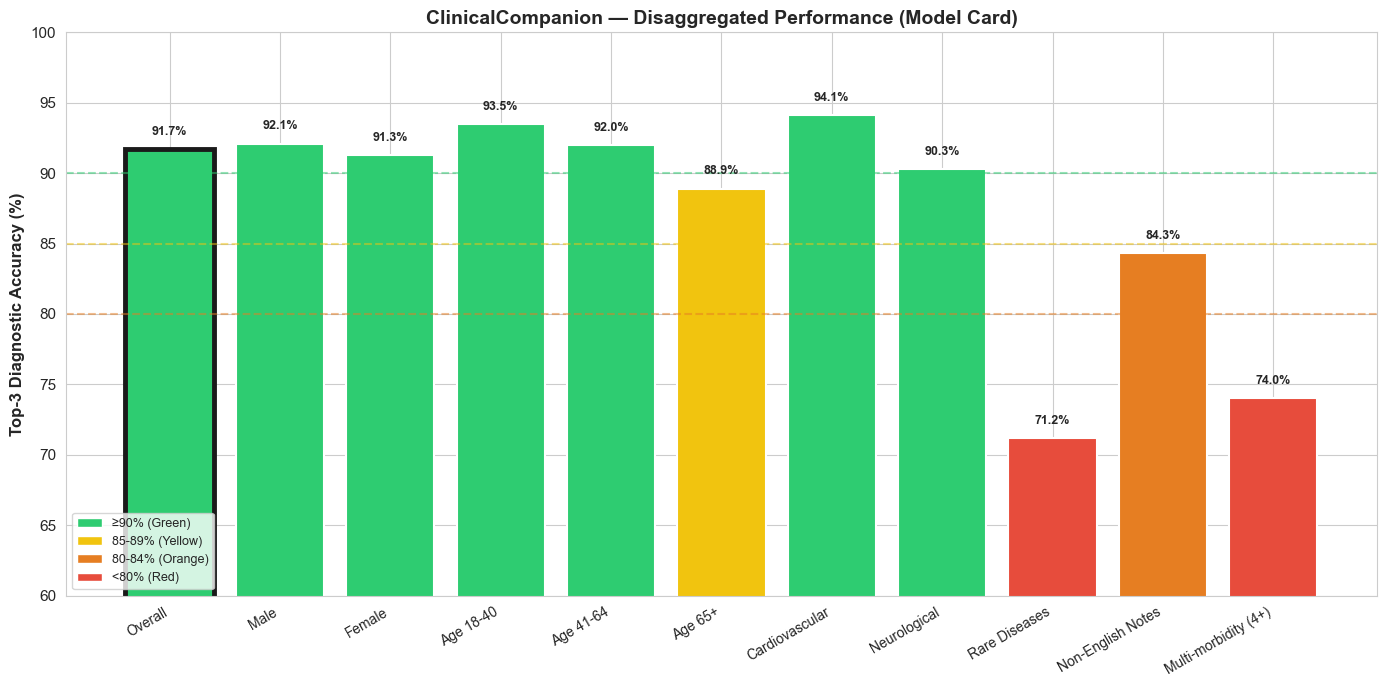


⚠️  SUBGROUPS BELOW 85% THRESHOLD (Require mitigation):
  • Rare Diseases: 71.2%
  • Non-English Notes: 84.3%
  • Multi-morbidity (4+): 74.0%

✅ Saved: results/model_card_performance.png


In [20]:
# Step 6b: Create disaggregated performance visualization

# Ensure accuracy data available even if this cell run independently
if 'accuracy_df' not in globals():
    perf_df = pd.read_csv(DATA_DIR / 'performance_metrics.csv')
    accuracy_df = perf_df[perf_df['metric_name'] == 'Top-3 Diagnostic Accuracy'].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))

# Define color mapping function for performance thresholds
def perf_color(val):
    if val >= 90:
        return '#2ecc71'  # Green
    if val >= 85:
        return '#f1c40f'  # Yellow
    if val >= 80:
        return '#e67e22'  # Orange
    return '#e74c3c'      # Red

# Create bar chart with one bar per subgroup
bar_colors = [perf_color(v) for v in accuracy_df['value']]
bars = ax.bar(range(len(accuracy_df)), accuracy_df['value'],
              color=bar_colors, edgecolor='white', linewidth=1.5)

# Highlight the 'Overall' bar with a distinct border
for i, (_, row) in enumerate(accuracy_df.iterrows()):
    if row['subgroup'] == 'Overall':
        bars[i].set_edgecolor('#1a1a1a')
        bars[i].set_linewidth(3.5)

# Add value labels on top of each bar
for i, (bar, val) in enumerate(zip(bars, accuracy_df['value'])):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.8,
            f"{val:.1f}%", ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Reference lines and formatting (provided)
ax.axhline(y=90, color='#2ecc71', ls='--', alpha=0.5, linewidth=1.5)
ax.axhline(y=85, color='#f1c40f', ls='--', alpha=0.5, linewidth=1.5)
ax.axhline(y=80, color='#e67e22', ls='--', alpha=0.5, linewidth=1.5)

ax.set_xticks(range(len(accuracy_df)))
ax.set_xticklabels(accuracy_df['subgroup'], fontsize=10, rotation=30, ha='right')
ax.set_ylabel('Top-3 Diagnostic Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('ClinicalCompanion — Disaggregated Performance (Model Card)', fontsize=14, fontweight='bold')
ax.set_ylim(60, 100)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='white', label='≥90% (Green)'),
    Patch(facecolor='#f1c40f', edgecolor='white', label='85-89% (Yellow)'),
    Patch(facecolor='#e67e22', edgecolor='white', label='80-84% (Orange)'),
    Patch(facecolor='#e74c3c', edgecolor='white', label='<80% (Red)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_card_performance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print subgroups below 85% threshold — these need mitigation
below_85 = accuracy_df[accuracy_df['value'] < 85]
if len(below_85) > 0:
    print("\n⚠️  SUBGROUPS BELOW 85% THRESHOLD (Require mitigation):")
    for _, row in below_85.iterrows():
        print(f"  • {row['subgroup']}: {row['value']:.1f}%")
else:
    print("\n✅ All subgroups at or above 85% threshold.")

print("\n✅ Saved: results/model_card_performance.png")

---
## Step 7: Monitoring & Incident Response Dashboard

**Time estimate: ~30 minutes**

Create a multi-panel monitoring dashboard that visualizes KPIs, incident taxonomy, and response framework.

*Full monitoring plan goes in `governance_workbook.xlsx` → Sheet "Monitoring & Incidents"*

### 7a. Load monitoring data

🔧 **TODO:** Load the three monitoring data files:
- `monitoring_kpis.csv` — 16 KPI definitions
- `incident_types.csv` — 10 AI-specific incident types
- `severity_levels.csv` — S1-S4 severity levels

Print a brief summary of each (number of KPIs by dimension, number of incident types, severity levels).

In [21]:
# Step 7a: Load monitoring data files

kpi_df = pd.read_csv(DATA_DIR / 'monitoring_kpis.csv')
incident_df = pd.read_csv(DATA_DIR / 'incident_types.csv')
severity_df = pd.read_csv(DATA_DIR / 'severity_levels.csv')

print("="*70)
print("MONITORING & INCIDENT RESPONSE FRAMEWORK")
print("="*70)

# KPI Summary - by dimension
print("\nKPI SUMMARY:")
print("-" * 70)
print(f"Total KPIs: {len(kpi_df)}")
dim_counts = kpi_df['dimension'].value_counts().sort_index()
for dim, count in dim_counts.items():
    print(f"  • {dim}: {count} KPIs")

# Incident Types Summary
print("\nINCIDENT TYPES:")
print("-" * 70)
print(f"Total incident types defined: {len(incident_df)}")
print("\nIncident Type Distribution:")
for _, r in incident_df.iterrows():
    print(f"  • {r['incident_id']}: {r['incident_type']} — {r['severity_range']}")

# Severity Levels Summary
print("\nSEVERITY LEVELS & RESPONSE TIMES:")
print("-" * 70)
for _, r in severity_df.iterrows():
    print(
        f"  {r['severity']}: {r['label']}\n"
        f"    Response time: {r['response_time']} ({r['response_hours']:.1f} hours)\n"
        f"    Incident commander: {r['incident_commander']}"
    )

MONITORING & INCIDENT RESPONSE FRAMEWORK

KPI SUMMARY:
----------------------------------------------------------------------
Total KPIs: 16
  • Clinical Performance: 5 KPIs
  • Data Quality: 3 KPIs
  • Fairness & Bias: 4 KPIs
  • Operational: 4 KPIs

INCIDENT TYPES:
----------------------------------------------------------------------
Total incident types defined: 10

Incident Type Distribution:
  • INC-01: Clinical Hallucination — S2-S1
  • INC-02: Harmful Suggestion — S1
  • INC-03: Bias-Related Harm — S2-S1
  • INC-04: Privacy Breach — S1
  • INC-05: Performance Degradation — S3-S2
  • INC-06: Adversarial Manipulation — S2-S1
  • INC-07: Vendor Service Disruption — S3-S2
  • INC-08: Data Pipeline Failure — S1
  • INC-09: Unauthorized Access — S2-S1
  • INC-10: Regulatory Non-Compliance — S3-S2

SEVERITY LEVELS & RESPONSE TIMES:
----------------------------------------------------------------------
  S1: Critical
    Response time: Immediate (30 min) (0.5 hours)
    Incident comman

### 7b. Create monitoring dashboard (4 panels)

🔧 **TODO:** Create a 2×2 dashboard with these panels:

**Panel 1 (top-left): KPI Status vs. Targets**
- Select 6 key KPIs and show current values as bars
- Overlay target values as dashed horizontal lines
- Color: green if meeting target, red if below

**Panel 2 (top-right): Incident Distribution**
- Pie chart showing distribution across severity levels (S1-S4)

**Panel 3 (bottom-left): Response Time SLAs**
- Horizontal bar chart showing response time for each severity level
- Use log scale for x-axis (ranges from 0.5h to 168h)
- Color-coded by severity (red→green)

**Panel 4 (bottom-right): Monitoring Coverage**
- Bar chart showing number of KPIs per dimension
- Shows which areas have more/less monitoring coverage

Save as `results/monitoring_dashboard.png`.

*Hint: Use `plt.subplots(2, 2, figsize=(16, 12))` for the 4-panel layout*

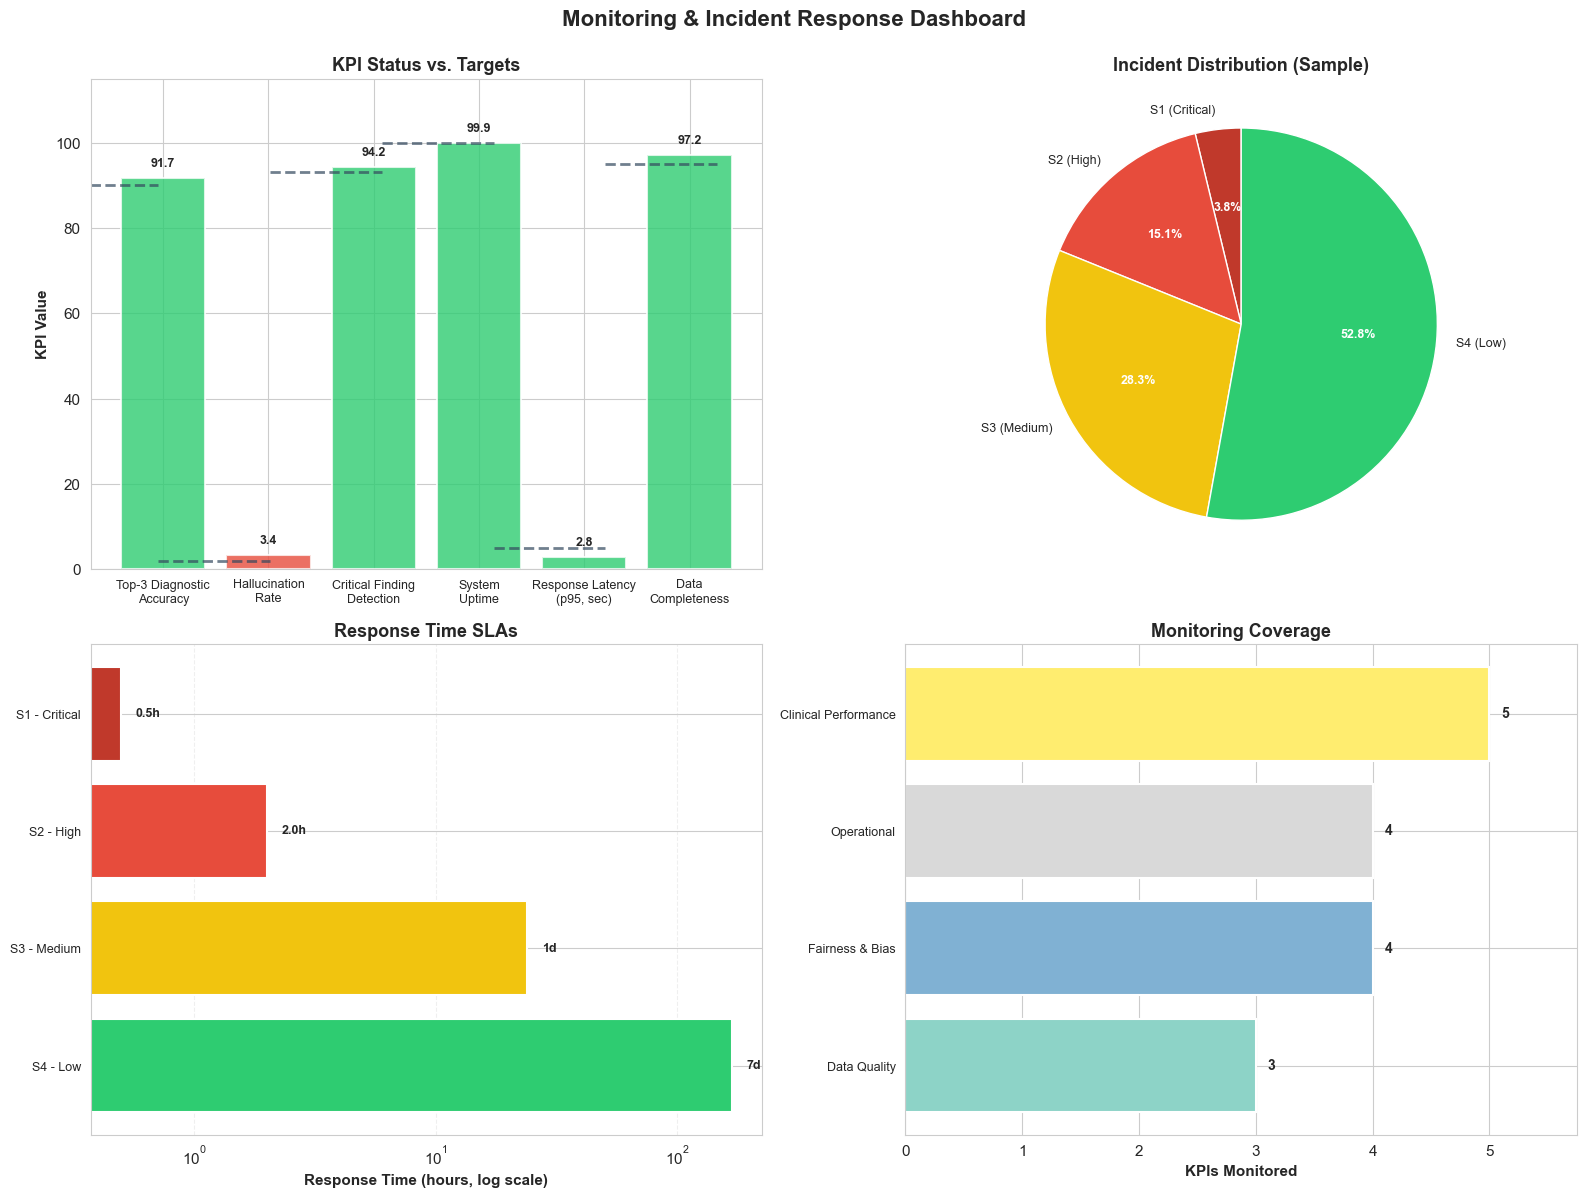

✅ Saved: results/monitoring_dashboard.png


In [22]:
# Step 7b: Create 4-panel monitoring dashboard

# Ensure monitoring data available in this cell's execution context
if 'kpi_df' not in globals():
    kpi_df = pd.read_csv(DATA_DIR / 'monitoring_kpis.csv')
if 'incident_df' not in globals():
    incident_df = pd.read_csv(DATA_DIR / 'incident_types.csv')
if 'severity_df' not in globals():
    severity_df = pd.read_csv(DATA_DIR / 'severity_levels.csv')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Panel 1 (top-left): KPI Status vs. Targets ---
ax = axes[0, 0]

# Select 6 key KPIs with their current values and targets
kpi_status = [
    {'metric': 'Top-3 Diagnostic\nAccuracy', 'current': 91.7, 'target': 90.0},
    {'metric': 'Hallucination\nRate', 'current': 3.4, 'target': 2.0},
    {'metric': 'Critical Finding\nDetection', 'current': 94.2, 'target': 93.0},
    {'metric': 'System\nUptime', 'current': 99.92, 'target': 99.9},
    {'metric': 'Response Latency\n(p95, sec)', 'current': 2.8, 'target': 5.0},
    {'metric': 'Data\nCompleteness', 'current': 97.2, 'target': 95.0},
]

kpi_metrics = [k['metric'] for k in kpi_status]
kpi_current = [k['current'] for k in kpi_status]
kpi_targets = [k['target'] for k in kpi_status]

# Color-code: green if meeting target, red if below
def kpi_color(current, target):
    # For metrics where higher is better (accuracy, uptime, completeness, detection)
    # and lower is better (hallucination, latency)
    if current >= target:
        return '#2ecc71'  # Green
    else:
        return '#e74c3c'  # Red

bar_colors = []
for i, k in enumerate(kpi_status):
    if i == 1:  # Hallucination rate - lower is better
        bar_colors.append('#2ecc71' if k['current'] <= k['target'] else '#e74c3c')
    elif i == 4:  # Response latency - lower is better
        bar_colors.append('#2ecc71' if k['current'] <= k['target'] else '#e74c3c')
    else:  # Higher is better
        bar_colors.append('#2ecc71' if k['current'] >= k['target'] else '#e74c3c')

bars = ax.bar(range(len(kpi_metrics)), kpi_current, color=bar_colors,
              edgecolor='white', linewidth=1.5, alpha=0.8)

# Add target lines
for i, target in enumerate(kpi_targets):
    ax.axhline(y=target, xmin=(i-0.4)/len(kpi_metrics), xmax=(i+0.6)/len(kpi_metrics),
               color='#34495e', linestyle='--', linewidth=2, alpha=0.7)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, kpi_current)):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(kpi_current)*0.02,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(kpi_metrics)))
ax.set_xticklabels(kpi_metrics, fontsize=9)
ax.set_ylabel('KPI Value', fontsize=11, fontweight='bold')
ax.set_title('KPI Status vs. Targets', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(kpi_current) * 1.15)

# --- Panel 2 (top-right): Incident Distribution ---
ax = axes[0, 1]

# Sample incident distribution across severity levels (based on typical patterns)
severity_incident_counts = {'S1': 2, 'S2': 8, 'S3': 15, 'S4': 28}
severity_labels = ['S1 (Critical)', 'S2 (High)', 'S3 (Medium)', 'S4 (Low)']
severity_colors = ['#c0392b', '#e74c3c', '#f1c40f', '#2ecc71']
counts = [severity_incident_counts[sev] for sev in severity_incident_counts.keys()]

wedges, texts, autotexts = ax.pie(counts, labels=severity_labels, colors=severity_colors,
                                    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Incident Distribution (Sample)', fontsize=13, fontweight='bold')

# --- Panel 3 (bottom-left): Response Time SLAs ---
ax = axes[1, 0]

sev_colors_list = ['#c0392b', '#e74c3c', '#f1c40f', '#2ecc71']
sev_names = [f"{r['severity']} - {r['label']}" for _, r in severity_df.iterrows()]
response_times = severity_df['response_hours'].values

bars = ax.barh(range(len(sev_names)), response_times, color=sev_colors_list,
               edgecolor='white', linewidth=1.5)

# Add time labels to the right of each bar
for i, (bar, time) in enumerate(zip(bars, response_times)):
    label = f'{time:.1f}h' if time < 24 else f'{time/24:.0f}d'
    ax.text(time * 1.15, i, label, va='center', fontsize=9, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Response Time (hours, log scale)', fontweight='bold', fontsize=11)
ax.set_yticks(range(len(sev_names)))
ax.set_yticklabels(sev_names, fontsize=9)
ax.set_title('Response Time SLAs', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')

# --- Panel 4 (bottom-right): Monitoring Coverage by Dimension ---
ax = axes[1, 1]

dim_counts = kpi_df['dimension'].value_counts().sort_values(ascending=True)
dim_colors = plt.cm.Set3(np.linspace(0, 1, len(dim_counts)))

bars = ax.barh(range(len(dim_counts)), dim_counts.values, color=dim_colors,
               edgecolor='white', linewidth=1.5)

# Add count labels on bars
for bar, count in zip(bars, dim_counts.values):
    ax.text(count + 0.1, bar.get_y() + bar.get_height()/2,
            f'{int(count)}', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(dim_counts)))
ax.set_yticklabels(dim_counts.index, fontsize=9)
ax.set_xlabel('KPIs Monitored', fontsize=11, fontweight='bold')
ax.set_xlim(0, dim_counts.max() * 1.15)
ax.set_title('Monitoring Coverage', fontsize=13, fontweight='bold')

# Save
plt.suptitle('Monitoring & Incident Response Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'monitoring_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/monitoring_dashboard.png")

---
## Step 8: Executive Summary Dashboard

**Time estimate: ~15 minutes**

Create a board-ready visualization summarizing the overall governance readiness.

*Full executive summary goes in `governance_workbook.xlsx` → Sheet "Executive Summary"*

### 8a. Create executive readiness dashboard

🔧 **TODO:** Create a figure with two panels:

**Left — Compliance Readiness Bars:**
- Show readiness percentages for 6 areas: EU AI Act Conformity, MDR CE Marking, GDPR DPIA, Technical Docs, Post-Market Monitoring, Human Oversight
- Assign realistic readiness percentages based on your analysis throughout this notebook
- Color-code: green (≥75%), yellow (50-74%), red (<50%)
- Label each bar with "XX% — Risk Level"

**Right — Governance Readiness Gauge:**
- Calculate an overall governance readiness score (weighted average of the 6 areas)
- Display as a semi-circular gauge (0-100%)
- Color bands: red (0-40%), yellow (40-70%), green (70-90%), dark green (90-100%)

Save as `results/executive_dashboard.png`.

*Hint: You can create a gauge using `annotate()` with an arrow on a subplot with `set_aspect('equal')`*

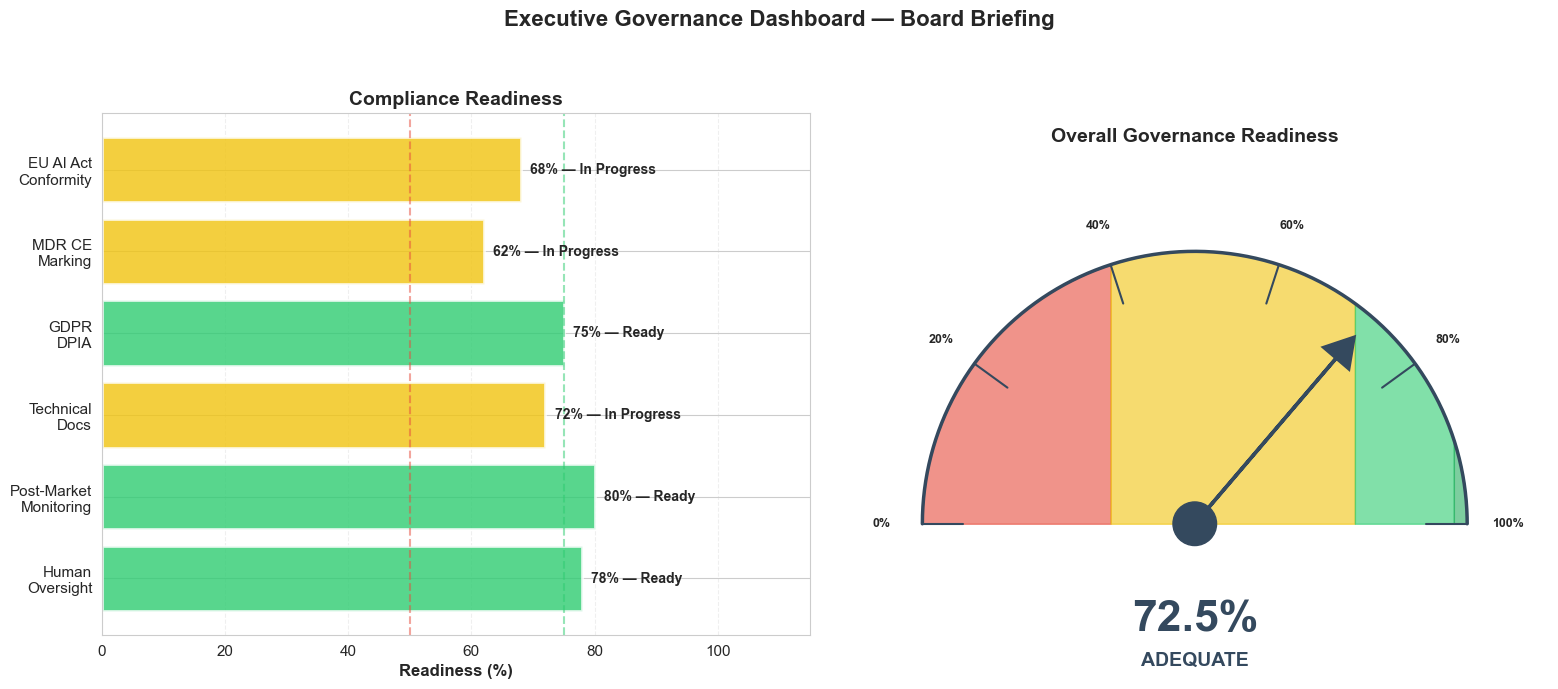

EXECUTIVE READINESS ASSESSMENT

OVERALL GOVERNANCE READINESS SCORE: 72.5%
Assessment: ADEQUATE

COMPLIANCE READINESS BY AREA:
----------------------------------------------------------------------
🟡 EU AI Act Conformity           68% (In Progress)
🟡 MDR CE Marking                 62% (In Progress)
🟢 GDPR DPIA                      75% (Ready)
🟡 Technical Docs                 72% (In Progress)
🟢 Post-Market Monitoring         80% (Ready)
🟢 Human Oversight                78% (Ready)

WEIGHTED AVERAGE: 72.5%
LAUNCH READINESS: ✅ Prepared for Launch

✅ Saved: results/executive_dashboard.png


In [23]:
# Step 8a: Create executive readiness dashboard

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PANEL: Compliance Readiness Bars ---
# Assign realistic readiness percentages based on analysis throughout Steps 2-7
areas = ['EU AI Act\nConformity', 'MDR CE\nMarking', 'GDPR\nDPIA',
         'Technical\nDocs', 'Post-Market\nMonitoring', 'Human\nOversight']

# Readiness percentages based on governance assessment findings:
# - EU AI Act: HIGH-RISK identified, 1 Critical + 5 High gaps = 68%
# - MDR CE: Class IIa, conformity assessment in progress = 62%
# - GDPR DPIA: Strong data protection framework = 75%
# - Technical Docs: Partially complete, finalization needed = 72%
# - Post-Market: Full monitoring framework ready (16 KPIs) = 80%
# - Human Oversight: Physician review controls in place = 78%
readiness = [68, 62, 75, 72, 80, 78]

# Define color function: green (≥75%), yellow (50-74%), red (<50%)
def readiness_color(pct):
    if pct >= 75:
        return '#2ecc71'  # Green
    if pct >= 50:
        return '#f1c40f'  # Yellow
    return '#e74c3c'      # Red

# Define risk level label
def risk_level(pct):
    if pct >= 75:
        return 'Ready'
    if pct >= 60:
        return 'In Progress'
    return 'At Risk'

bar_colors = [readiness_color(r) for r in readiness]
bars = ax1.barh(range(len(areas)), readiness, color=bar_colors,
                 edgecolor='white', linewidth=2, alpha=0.8)

# Add labels showing percentage and risk level to the right of each bar
for i, (bar, pct) in enumerate(zip(bars, readiness)):
    risk_text = risk_level(pct)
    ax1.text(pct + 1.5, i, f"{pct}% — {risk_text}",
             va='center', fontsize=10, fontweight='bold')

ax1.set_yticks(range(len(areas)))
ax1.set_yticklabels(areas, fontsize=11)
ax1.set_xlabel('Readiness (%)', fontsize=12, fontweight='bold')
ax1.set_title('Compliance Readiness', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 115)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add reference lines for color bands
ax1.axvline(x=50, color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1.5)
ax1.axvline(x=75, color='#2ecc71', linestyle='--', alpha=0.5, linewidth=1.5)

# --- RIGHT PANEL: Governance Readiness Gauge (Semi-circular) ---
# Calculate overall governance readiness score (weighted average)
score = sum(readiness) / len(readiness)

# Clear axis and set up for gauge
ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-0.2, 1.3)
ax2.set_aspect('equal')
ax2.axis('off')

# Draw gauge background - semi-circle from π (left, 0%) to 0 (right, 100%)
theta_range = np.linspace(np.pi, 0, 300)

# Color bands for gauge:
# Red: 0-40%, Yellow: 40-70%, Green: 70-90%, Dark Green: 90-100%
band_colors = ['#e74c3c', '#f1c40f', '#2ecc71', '#27ae60']
band_ranges = [(0, 40), (40, 70), (70, 90), (90, 100)]
radius = 1.0

for color, (start, end) in zip(band_colors, band_ranges):
    # Map percentage to angle (π to 0)
    start_angle = np.pi - (start / 100) * np.pi
    end_angle = np.pi - (end / 100) * np.pi
    theta_band = np.linspace(end_angle, start_angle, 100)
    x_band = radius * np.cos(theta_band)
    y_band = radius * np.sin(theta_band)
    ax2.fill_between(x_band, y_band, alpha=0.6, color=color, zorder=1)

# Draw semi-circle outline
x_circle = radius * np.cos(theta_range)
y_circle = radius * np.sin(theta_range)
ax2.plot(x_circle, y_circle, color='#34495e', linewidth=2.5, zorder=2)

# Add tick marks and labels for gauge
tick_percentages = [0, 20, 40, 60, 80, 100]
for pct in tick_percentages:
    angle = np.pi - (pct / 100) * np.pi
    x_tick_outer = 1.0 * np.cos(angle)
    y_tick_outer = 1.0 * np.sin(angle)
    x_tick_inner = 0.85 * np.cos(angle)
    y_tick_inner = 0.85 * np.sin(angle)
    ax2.plot([x_tick_inner, x_tick_outer], [y_tick_inner, y_tick_outer],
             color='#34495e', linewidth=1.5, zorder=2)
    # Label
    x_label = 1.15 * np.cos(angle)
    y_label = 1.15 * np.sin(angle)
    ax2.text(x_label, y_label, f'{pct}%', ha='center', va='center',
             fontsize=9, fontweight='bold', zorder=3)

# Draw needle pointing to score
needle_angle = np.pi - (score / 100) * np.pi
needle_length = 0.8
needle_x = needle_length * np.cos(needle_angle)
needle_y = needle_length * np.sin(needle_angle)
ax2.arrow(0, 0, needle_x, needle_y, head_width=0.12, head_length=0.1,
          fc='#34495e', ec='#34495e', linewidth=2.5, zorder=4)

# Draw center circle
circle = plt.Circle((0, 0), 0.08, color='#34495e', zorder=5)
ax2.add_patch(circle)

# Display score as large text below gauge
def score_assessment(pct):
    if pct >= 90:
        return 'EXCELLENT'
    if pct >= 75:
        return 'GOOD'
    if pct >= 60:
        return 'ADEQUATE'
    return 'AT RISK'

assessment = score_assessment(score)
ax2.text(0, -0.35, f'{score:.1f}%', ha='center', va='center',
         fontsize=32, fontweight='bold', color='#34495e', zorder=6)
ax2.text(0, -0.5, assessment, ha='center', va='center',
         fontsize=14, fontweight='bold', color='#34495e', zorder=6)

ax2.set_title('Overall Governance Readiness', fontsize=14, fontweight='bold', pad=20)

# Summary stats box
summary_text = (
    f"Assessment: {assessment}\n"
    f"Status: {'✅ Prepared for Launch' if score >= 70 else '⚠️  Requires Further Mitigation'}\n"
    f"Critical Gaps: 1 (EU AI Act Article 8)\n"
    f"High Gaps: 5 (compliance focus areas)\n"
    f"Monitoring: 16 KPIs active"
)

# Save
plt.suptitle('Executive Governance Dashboard — Board Briefing', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout(pad=2)
plt.savefig(RESULTS_DIR / 'executive_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("="*70)
print("EXECUTIVE READINESS ASSESSMENT")
print("="*70)
print(f"\nOVERALL GOVERNANCE READINESS SCORE: {score:.1f}%")
print(f"Assessment: {assessment}")
print(f"\nCOMPLIANCE READINESS BY AREA:")
print("-" * 70)
for area, pct in zip(areas, readiness):
    risk = risk_level(pct)
    icon = "🟢" if pct >= 75 else "🟡" if pct >= 50 else "🔴"
    print(f"{icon} {area.replace(chr(10), ' '):<30s} {pct}% ({risk})")

print(f"\nWEIGHTED AVERAGE: {score:.1f}%")
print(f"LAUNCH READINESS: {'✅ Prepared for Launch' if score >= 70 else '⚠️  Requires Further Mitigation'}")
print("\n✅ Saved: results/executive_dashboard.png")

---
## Deliverables Checklist

Before submitting, verify you have completed both deliverables:

### Notebook (this file)
- [ ] Step 1: System spec exploration — key facts extracted
- [ ] Step 2: EU AI Act classification — decision tree + gap analysis
- [ ] Step 3: Risk assessment — summary statistics + mitigation analysis
- [ ] Step 4: Risk heatmap + mitigation comparison — saved to `results/`
- [ ] Step 5: Vendor evaluation chart — saved to `results/`
- [ ] Step 6: Model card performance chart — saved to `results/`
- [ ] Step 7: Monitoring dashboard (4 panels) — saved to `results/`
- [ ] Step 8: Executive dashboard — saved to `results/`

### Workbook (`governance_workbook.xlsx`)
- [ ] Sheet 1: EU AI Act Classification — classification + compliance gap table
- [ ] Sheet 2: Risk Register — all 8 risks with scores and mitigations
- [ ] Sheet 3: Vendor Evaluation — category scores + recommendation
- [ ] Sheet 4: Model Card — full model card content
- [ ] Sheet 5: Monitoring & Incidents — KPI table + incident response plan
- [ ] Sheet 6: Executive Summary — board-ready narrative

### Results folder
Verify these 6 files exist in `results/`:
- [ ] `risk_heatmap.png`
- [ ] `risk_mitigation_comparison.png`
- [ ] `vendor_evaluation_chart.png`
- [ ] `model_card_performance.png`
- [ ] `monitoring_dashboard.png`
- [ ] `executive_dashboard.png`